## Tarea 5 - Análisis de texto

## Nombre: Sergio Trejo

## Matricula: 261539

## Materia: Procesamiento de lenguaje natural_A_Presencial_260206

## Análisis de texto

**Analice el siguiente texto y aplique las técnicas de PLN que crea necesarias (nube de palabras, gráficas, lemas, stopwords, limpieza, etc.). Instale las librearías necesarias. Desarrolle su script de Python implementando el código en funciones. Describa el efecto de las técnicas utilizadas al ser aplicadas al texto al ser procesado.**

In [42]:
import re
import spacy
import nltk
import unicodedata
import matplotlib.pyplot as plt
from collections import  Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nlp = spacy.load('es_core_news_sm')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [34]:
texto = """En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.

@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.

Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.

El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital

Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial

y la inteligencia artificial aparecen repetidamente en los debates académicos"""



In [35]:
#Funcion de limpieza de normalizacion

def eliminar_acentos(texto):
    texto_normalizado = unicodedata.normalize('NFD', texto)

    resultado = ""
    for caracter in texto_normalizado:
        if unicodedata.category(caracter) != 'Mn': #si no es una marca de acento (Mn = Mark Nonspacing)
            resultado += caracter
    return resultado

def limpiar_texto(texto, quitar_acentos=False):
    texto = texto.lower() #convertir a minusculas
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto) #elimnar patrones de URLs
    texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto) #elimnar correos electronicos
    texto = re.sub(r'@\w+', '', texto) #eliminar menciones ejemplo: @usuario
    texto = re.sub(r'#\w+', '', texto) #eliminar hashtags
    texto = re.sub(r'\d+', '', texto) #eliminar numeros
    texto = re.sub(r'[^\w\s]', '', texto) #eliminar caracteres especiales
    texto = re.sub(r'\s+', ' ', texto) #eliminar espacios en blanco

    if quitar_acentos:
      texto = eliminar_acentos(texto)
    return texto


**Conclusion**

En esta parte se realizo la limpieza del texto para eliminar elemntos que no aportan valor al analisis, como URLs, correos electronicos, menciones, hashtags, numeros y caracteres especiales. Tambien se convirtio todo el texto en minusculas para evitar que una misma palabra sea contada como diferente por el uso de mayusculas.La opcion de eliminar los acentos permite reducir variaciones ortograficas y unificar palabras similares. En general, esta fase mejora la calidad del texto y prepara la informacion para aplicar tecnicas posteriores a la tokenizacion y lematizacion de mejor manera.

In [36]:
#Tokenizacion
def tokenizacion(texto):
  return nltk.word_tokenize(texto, language='spanish')

print("Texto tokenizado:")
print(tokenizacion(texto))

Texto tokenizado:
['En', 'el', 'Congreso', 'Internacional', 'de', 'Inteligencia', 'Artificial', '2025', 'se', 'discutieron', 'avances', 'muy', 'importantes', '.', '@', 'Maria', 'comentó', 'que', 'la', 'ética', 'de', 'la', 'IA', 'debe', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'las', 'investigaciones', '.', 'Puedes', 'leer', 'más', 'en', 'http', ':', '//ia-congreso2025.org', 'o', 'enviar', 'tus', 'dudas', 'al', 'correo', 'contacto', '@', 'ia2025.org', '.', 'El', 'Dr.', 'Pérez', 'afirmó', ':', '``', '¡La', 'innovación', 'no', 'se', 'detiene', '!', "''", '.', '#', 'InteligenciaArtificial', '#', 'ÉticaDigital', 'Además', ',', 'varios', 'expertos', 'señalaron', 'que', 'la', 'inteligencia', 'artificial', ',', 'la', 'inteligencia', 'artificial', 'y', 'la', 'inteligencia', 'artificial', 'aparecen', 'repetidamente', 'en', 'los', 'debates', 'académicos']


**Conclusion**

Se realizo la tokenizacion del texto, que consiste en dividir el contenido en palabras individuales llamadas tokens. Esto permite transformar el texto completo en una lista que puede ser analizada de forma mas estructurada. La tokenizacion facilita el conteo de palabras, l;a eliminacion de stopwords y la aplicacion de tecnicas como lematizacion. En general, la tokenizacion convierte el texto en una forma mas manejable.

In [37]:
#Lematizacion
def lematizacion(texto): #reducir cada palabra a su forma base (lema)

  doc = nlp(texto)
  lemmas = [token.lemma_ for token in doc]
  return lemmas

texto_limpio = limpiar_texto(texto)
lemmas = lematizacion(texto_limpio)

print("Texto lematizado:")
print(lematizacion(texto))


Texto lematizado:
['en', 'el', 'Congreso', 'Internacional', 'de', 'Inteligencia', 'Artificial', '2025', 'él', 'discutir', 'avance', 'mucho', 'importante', '.', '\n\n', '@mario', 'comentar', 'que', 'el', 'ética', 'de', 'el', 'IA', 'deber', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'el', 'investigación', '.', '\n\n', 'Puedes', 'leer', 'más', 'en', 'http://ia-congreso2025.org', 'o', 'enviar', 'tu', 'duda', 'al', 'correo', 'contacto@ia2025.org', '.', '\n\n', 'el', 'Dr.', 'Pérez', 'afirmar', ':', '"', '¡', 'el', 'innovación', 'no', 'él', 'detener', '!', '"', '.', '#', 'InteligenciaArtificial', '#', 'éticadigital', '\n\n', 'además', ',', 'varios', 'experto', 'señalar', 'que', 'el', 'inteligencia', 'artificial', ',', 'el', 'inteligencia', 'artificial', '\n\n', 'y', 'el', 'inteligencia', 'artificial', 'aparecer', 'repetidamente', 'en', 'el', 'debate', 'académico']


**Conclusion**

Aqui se aplico la lematizacion al texto limpio, lo que permite reducir cada palabra a su forma base o lema. Por ejemplo, palabras como "discutieron" se transformo a "discutir", lo que ayuda a unificar diferentes formas de una misma palabra. Esto nos ayuda a reducir la cantidad de variaciones en el vocabulario y facilita el analisis de frecuencias. La lematizacion nos ayuda a que el analisis sea mas concreto al enfocarse en la forma base de la palabra.

In [38]:
#Eliminacion de stopwords
def eliminar_stopwords(texto):
  stop_words = set(stopwords.words('spanish'))
  tokens_filtrados = [palabra for palabra in texto if palabra not in stop_words and palabra.isalpha()]
  return tokens_filtrados

print("Texto sin stopwords:")
print(eliminar_stopwords(lemmas))

Texto sin stopwords:
['congreso', 'internacional', 'inteligencia', 'artificial', 'discutir', 'avance', 'importante', 'comentar', 'ética', 'ia', 'deber', 'siempre', 'centro', 'investigación', 'poder', 'leer', 'enviar', 'duda', 'correo', 'dr', 'pérez', 'afirmar', 'innovación', 'detener', 'además', 'varios', 'experto', 'señalar', 'inteligencia', 'artificial', 'inteligencia', 'artificial', 'inteligencia', 'artificial', 'aparecer', 'repetidamente', 'debate', 'académico']


**Conclusion**

En esta etapa se eliminaron las stopwords, que son palabras muy comunes como “el”, “la”, “de” o “que”, las cuales no aportan mucho significado al analisis del texto. Al quitarlas, el resultado se enfoca mas en las palabras que realmente agregan valor al contexto o tema principal. Esto ayuda a que las graficas de frecuencia y la nube de palabras reflejen mejor el contenido importante. Esta fase permite obtener una representacion mas clara y significativa del texto analizado.

In [39]:
#Frecuencias de texto
def obtener_frecuencias(texto):
    return Counter(texto)

frecuencias = obtener_frecuencias(eliminar_stopwords(lemmas))
print("Frecuencias de palabras:")
print(frecuencias)


Frecuencias de palabras:
Counter({'inteligencia': 4, 'artificial': 4, 'congreso': 1, 'internacional': 1, 'discutir': 1, 'avance': 1, 'importante': 1, 'comentar': 1, 'ética': 1, 'ia': 1, 'deber': 1, 'siempre': 1, 'centro': 1, 'investigación': 1, 'poder': 1, 'leer': 1, 'enviar': 1, 'duda': 1, 'correo': 1, 'dr': 1, 'pérez': 1, 'afirmar': 1, 'innovación': 1, 'detener': 1, 'además': 1, 'varios': 1, 'experto': 1, 'señalar': 1, 'aparecer': 1, 'repetidamente': 1, 'debate': 1, 'académico': 1})


**Conclusion**

En esta etapa se calcularon las frecuencias de las palabras utilizando un contador, lo que nos permite saber cuantas veces aparece cada palabra en el texto procesado. Esto ayuda a identificar cuales son las palabras mas repetidas y por lo tanto, las mas relevantes dentro del contenido. Al aplicar este conteo despues de eliminar stopwords y lematizar, los resultados reflejan mejor el tema central del texto. En general, el analisis de frecuencias permite obtener una vision mas precisa de las palabras mas importantes.

In [40]:
#Grafica de frecuencias
def graficar_frecuencias(texto, titulo):

    contador = Counter(texto)
    comunes = contador.most_common(10)

    palabras, frecuencias = zip(*comunes)
    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias)
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(titulo)
    plt.xticks(rotation=45)
    plt.show()


**Conclusion**

En esta etapa se genero una grafica de barras con las palabras mas frecuentes del texto procesado. Esto permite visualizar de manera clara cuales son los terminos que aparecen con mayor repeticion.

In [41]:
#WordCloud

def generar_wordcloud(tokens, titulo):

    texto_unido = " ".join(tokens)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(texto_unido)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo)
    plt.show()

**Conclusion**

La nube de palabras se genero apartir del texto procesado. COn esta tecnica nos permite visualizar de forma grafica cuales son las palabras que aparecen con mayor frecuencia, ya que las palabras mas repetidas se muestran con una tamaño mas grande. La nube facilita identificar rapidamente el tema central del texto sin necesidad de revisar cada palabra individualmente.

Texto limpio:
en el congreso internacional de inteligencia artificial se discutieron avances muy importantes comentó que la ética de la ia debe estar siempre en el centro de las investigaciones puedes leer más en o enviar tus dudas al correo el dr pérez afirmó la innovación no se detiene además varios expertos señalaron que la inteligencia artificial la inteligencia artificial y la inteligencia artificial aparecen repetidamente en los debates académicos

Tokens:
['en', 'el', 'congreso', 'internacional', 'de', 'inteligencia', 'artificial', 'se', 'discutieron', 'avances', 'muy', 'importantes', 'comentó', 'que', 'la', 'ética', 'de', 'la', 'ia', 'debe', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'las', 'investigaciones', 'puedes', 'leer', 'más', 'en', 'o', 'enviar', 'tus', 'dudas', 'al', 'correo', 'el', 'dr', 'pérez', 'afirmó', 'la', 'innovación', 'no', 'se', 'detiene', 'además', 'varios', 'expertos', 'señalaron', 'que', 'la', 'inteligencia', 'artificial', 'la', 'inteligencia', 'artif

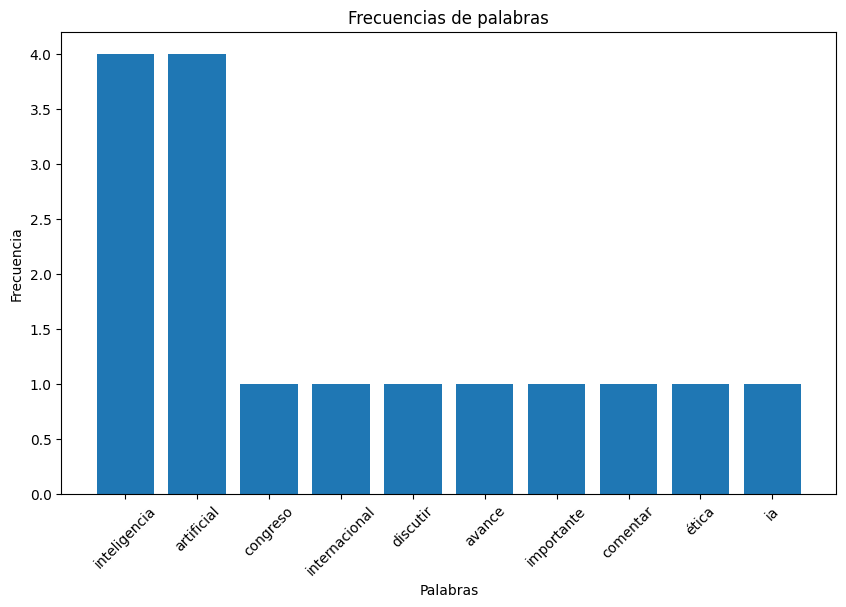

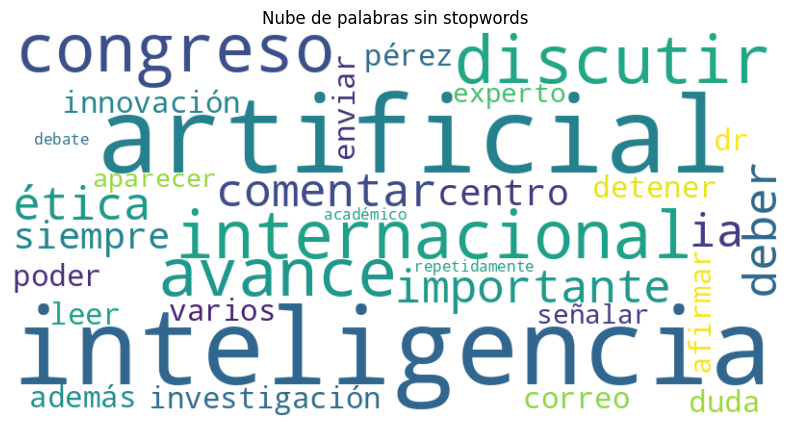

In [45]:
#Pipeline

#Limpieza de texto
texto_limpio = limpiar_texto(texto, quitar_acentos=False)
#Tokenizacion
tokens = tokenizacion(texto_limpio)
#Lematizacion
lemmas = lematizacion(texto_limpio)
#Eliminar stopwords
tokens_filtrados = eliminar_stopwords(lemmas)
#Frecuencia de palabras
frecuencias = obtener_frecuencias(eliminar_stopwords(lemmas))

#resultados
print("Texto limpio:")
print(texto_limpio)
print("\nTokens:")
print(tokens)
print("\nLemas:")
print(lemmas)
print("\nFrecuencias de palabras:")
print(frecuencias)

#visualizacion
graficar_frecuencias(frecuencias, 'Frecuencias de palabras')
generar_wordcloud(tokens_filtrados, 'Nube de palabras sin stopwords')





## **Conclusiones Finales**

Al aplicar las tecnicas de NPL al texto proporcionado, se pudo observar como el procesamiento transforma un texto crudo en informacion estructurada que es mas facil de analizar. Primero se limpio el texto quitando elementos que no aportan informacion importante, la lematizacion redujo variaciones de palabras y la eliminacion de stopwords permitio enfocarse en los terminos con mayor significado. Las graficas y la nube de palabras mostraron de forma visual que el tema principal esta relacionado con la inteligencia artificial. En conclusion, el uso de estas tecnicas ayudan a entender mejor el texto y a organizar la informacion de manera mas clara.